# Hierarchical Clustering from First Principles
## Customer Segmentation Using the Mall Customers Dataset

---

### Problem Definition

A shopping mall wants to understand its customer base. Today, the mall treats its customers largely as a single undifferentiated population, which makes it hard to design targeted marketing campaigns, loyalty programs, personalized promotions, or retention strategies.

**Business question:** *Can customers be grouped into meaningful segments based on similarities in age, annual income, and spending behavior?*

This notebook answers that question by implementing **Agglomerative Hierarchical Clustering entirely from first principles,** using only NumPy for the mathematics, and then validating that implementation against `scikit-learn` and benchmarking it against alternative clustering algorithms (K-Means, Gaussian Mixture Models, DBSCAN).

There is no ground-truth label in this dataset. The task is unsupervised: we are *discovering* structure, not predicting a known target. Every evaluation choice in this notebook follows from that fact. No classification accuracy, no train/test split of the usual kind, and heavy reliance on internal validation metrics (Silhouette, Calinski-Harabasz, Davies-Bouldin) plus business interpretability.

### Objectives

1. Implement Agglomerative Hierarchical Clustering from scratch (distance computation, linkage, merging, dendrogram construction, flat-cluster extraction).
2. Compare four linkage strategies: single, complete, average, and Ward.
3. Select a defensible number of clusters using dendrogram structure **and** internal validation metrics.
4. Validate the custom implementation against `sklearn.cluster.AgglomerativeClustering` using label-invariant metrics (Adjusted Rand Index, Normalized Mutual Information).
5. Benchmark against K-Means, Gaussian Mixture Models, and DBSCAN.
6. Profile the resulting clusters and translate them into business-relevant customer segments.
7. Explicitly document assumptions, limitations, and stability of the result.

### Constraints

- **Core implementation:** NumPy, Pandas, Matplotlib, Seaborn only. No `sklearn.cluster.AgglomerativeClustering` and no `scipy.cluster.hierarchy` linkage functions inside the from-scratch implementation.
- **Validation stage:** `scikit-learn` is explicitly permitted, but only *after* the custom implementation is complete, and only as an external reference.
- Every major code block is followed by a Markdown explanation of what it does, why, and what it implies for the next step.

### Initial Hypotheses

Before looking at any results, we state what we expect to find:

- **H1:** Income and spending score alone will produce clearer, more interpretable segmentation than demographic variables.
- **H2:** Ward linkage will produce more compact, business-interpretable clusters than single linkage (which is prone to chaining).
- **H3:** The optimal number of clusters will be small (roughly 4–6), small enough to be actionable for a marketing team.
- **H4:** The custom implementation will produce cluster structure broadly consistent with `sklearn`'s under the same linkage/metric configuration, though exact integer labels may differ (labels are permutation-invariant).
- **H5:** Different clustering algorithms (hierarchical, K-Means, GMM, DBSCAN) may disagree somewhat, because they assume different cluster geometries.
- **H6:** Adding Age as a third dimension will change cluster composition, but won't necessarily *improve* internal validation scores.

We will return to each of these in the final conclusion and state whether the evidence supported or contradicted them.

## Environment and Reproducibility

We record library versions and fix random seeds wherever an algorithm has stochastic behavior (K-Means initialization, Gaussian Mixture Model initialization, bootstrap resampling). Hierarchical clustering itself is deterministic given a dataset and a linkage rule, so no seed is required for the core algorithm.

The plotting style follows the same dark-theme convention used across this portfolio's other from-scratch notebooks, so results are visually consistent across projects.

In [1]:
# Core imports
import sys
import platform
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.lines as mlines
import seaborn as sns

warnings.filterwarnings("ignore")

# Reproducibility bookkeeping
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Python version:", sys.version.split()[0], f"({platform.platform()})")
for name, mod in [("numpy", np), ("pandas", pd), ("matplotlib", matplotlib), ("seaborn", sns)]:
    print(f"{name:12s}: {mod.__version__}")

import sklearn
print(f"{'scikit-learn':12s}: {sklearn.__version__}")

Python version: 3.14.6 (Windows-11-10.0.26200-SP0)
numpy       : 2.4.6
pandas      : 3.0.3
matplotlib  : 3.11.0
seaborn     : 0.13.2
scikit-learn: 1.9.0


In [2]:
# Dark-theme plotting style
FG    = "#e6e6e6"   # foreground / text
BG    = "#0d1117"   # figure background
PANEL = "#161b22"   # axes background
GRID  = "#30363d"   # gridlines
C0    = "#58a6ff"   # primary accent (blue)
C1    = "#f78166"   # secondary accent (orange)
TEAL  = "#39d3bb"
GOLD  = "#e3b341"

# A small qualitative palette built from the accent colors, used for clusters
CLUSTER_PALETTE = [C0, C1, TEAL, GOLD, "#d2a8ff", "#7ee787", "#ff7b72", "#79c0ff"]

def style():
    '''Apply the portfolio's consistent dark plotting theme to the current figure/axes.'''
    plt.rcParams.update({
        "figure.facecolor": BG,
        "axes.facecolor": PANEL,
        "axes.edgecolor": GRID,
        "axes.labelcolor": FG,
        "axes.titlecolor": FG,
        "text.color": FG,
        "xtick.color": FG,
        "ytick.color": FG,
        "grid.color": GRID,
        "legend.facecolor": PANEL,
        "legend.edgecolor": GRID,
        "legend.labelcolor": FG,
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.35,
        "savefig.facecolor": BG,
    })

style()
print("Plotting style configured.")

Plotting style configured.


## Data Loading

`scikit-learn` does not ship the Mall Customers dataset (it is not one of the bundled toy or fetchable datasets), so it is loaded from a hosted CSV mirror of the original Kaggle dataset.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"

df_raw = pd.read_csv(DATA_URL)
print(f"Loaded dataset from hosted source: {DATA_URL}")

df = df_raw.copy()
df.head()

Loaded dataset from hosted source: https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**What this shows:** the dataset loaded successfully with the expected five columns: `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`. `Spending Score` is a proprietary, mall-assigned metric (1–100) summarizing customer purchasing behavior, not a raw transaction total. We now audit the structure before doing anything else.

## Structural Audit

Before any modeling, we confirm the dataset's shape, types, ranges, and quality. This matters more than usual in clustering: because distance-based algorithms are sensitive to every numeric column we feed them, undetected duplicates, missing values, or an accidentally-included identifier column can silently distort the entire result.

In [4]:
print("Shape (rows, columns):", df.shape)
print()
print("Columns:", list(df.columns))
print()
df.info()

Shape (rows, columns): (200, 5)

Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [5]:
df.describe(include="all")

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


In [6]:
missing = df.isnull().sum()
dup_rows = df.duplicated().sum()
dup_ids = df["CustomerID"].duplicated().sum()

print("Missing values per column:")
print(missing)
print()
print(f"Fully duplicated rows: {dup_rows}")
print(f"Duplicate CustomerID values: {dup_ids}")
print()
print("Unique Gender values:", df["Gender"].unique().tolist())
print()
print("Numerical ranges:")
print(df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].agg(["min", "max"]).T)

Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Fully duplicated rows: 0
Duplicate CustomerID values: 0

Unique Gender values: ['Male', 'Female']

Numerical ranges:
                        min  max
Age                      18   70
Annual Income (k$)       15  137
Spending Score (1-100)    1   99


In [7]:
# CustomerID is a monotonically increasing identifier, confirm it carries no
# information beyond row order, so we can safely exclude it from clustering.
is_sequential = (df["CustomerID"].values == np.arange(1, len(df) + 1)).all()
print(f"CustomerID is a simple 1..N sequential identifier: {is_sequential}")
print("CustomerID will be EXCLUDED from all clustering features as it is an identifier, not a behavioral attribute.")

CustomerID is a simple 1..N sequential identifier: True
CustomerID will be EXCLUDED from all clustering features as it is an identifier, not a behavioral attribute.


**What the structural audit reveals:**

- **200 customers, 5 columns, no missing values, no duplicated rows or CustomerIDs.** This is a clean, small, well-behaved dataset, typical of an educational/benchmark dataset rather than raw production data.
- `CustomerID` is confirmed to be a plain sequential identifier (1 through 200). It carries no behavioral signal, so per the project constraints it is excluded from every clustering experiment.
- `Gender` is categorical with two levels (Male/Female). Per the project's data-handling instructions, it is **not** encoded into the primary clustering experiment. It will only be used afterward, descriptively, to profile the resulting clusters.
- `Age` ranges roughly 18–70, `Annual Income (k$)` roughly 15–137, and `Spending Score` is bounded 1–100 by construction. These three numeric columns live on very different scales, which is the first hint that **feature scaling will matter** once we compute Euclidean distances.
- No obvious data-quality issues (encoding errors, impossible values, sentinel codes) are present. We proceed to exploratory analysis.

## Exploratory Data Analysis

We look at distributions, relationships between variables, and potential outliers **before** clustering. The goal here is only to understand the data, not to declare that clusters exist just because a scatter plot looks visually grouped. Any "natural groupings" noted below are hypotheses to be tested quantitatively later, not conclusions.

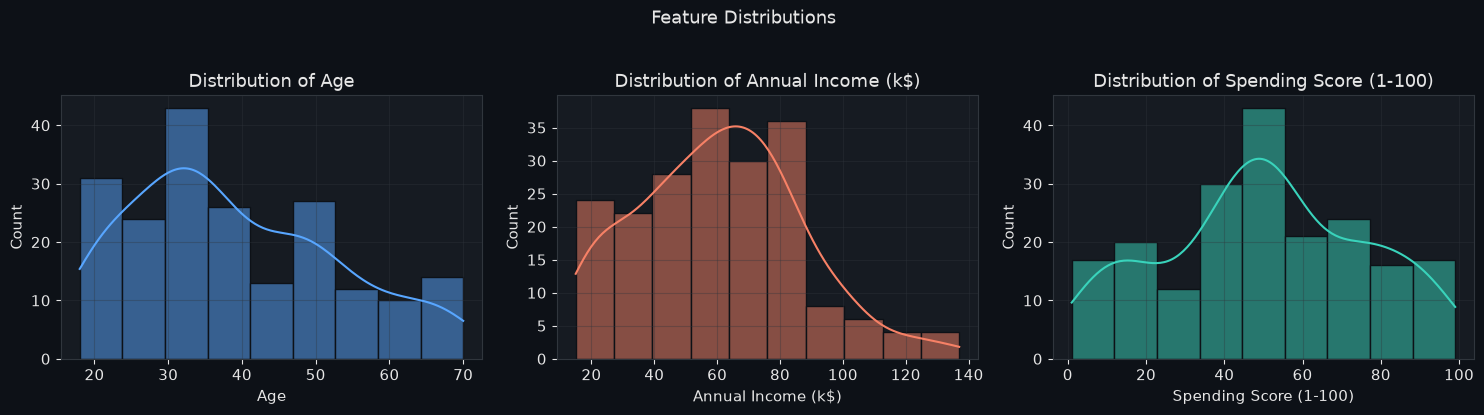

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
style()
numeric_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
colors = [C0, C1, TEAL]

for ax, col, c in zip(axes, numeric_cols, colors):
    sns.histplot(df[col], kde=True, ax=ax, color=c, edgecolor=BG)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)

fig.suptitle("Feature Distributions", color=FG, y=1.03)
plt.tight_layout()
plt.show()

**Interpretation:** `Age` is right-skewed with a concentration of customers in their 20s–30s and a long tail into the 60s. `Annual Income` is roughly unimodal with a mild right skew (a handful of high earners above $100k). `Spending Score` is close to uniform across its 1–100 range, which is expected for a score that was likely constructed by the mall to have broad coverage. None of the three shows multiple obvious modes on its own, any clustering structure is more likely to emerge from the *combination* of variables than from any single one.

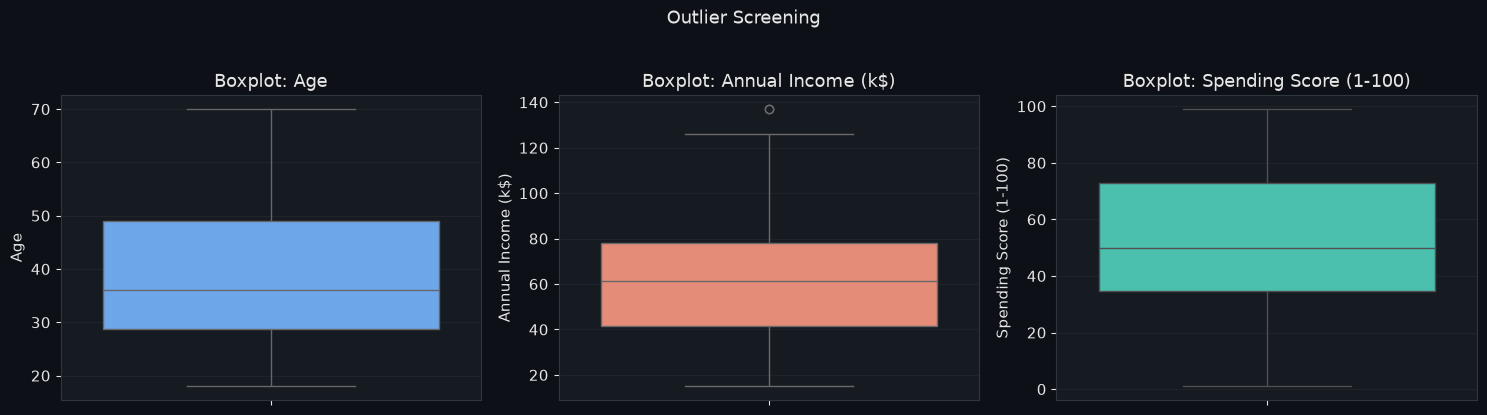

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
style()

for ax, col, c in zip(axes, numeric_cols, colors):
    sns.boxplot(y=df[col], ax=ax, color=c)
    ax.set_title(f"Boxplot: {col}")

fig.suptitle("Outlier Screening", color=FG, y=1.03)
plt.tight_layout()
plt.show()

**Interpretation:** none of the three numeric features shows extreme outliers by the standard IQR whisker convention. The boxplots show full, unclipped whiskers with no points flagged beyond them. This means we do not need an outlier-removal step before clustering, though we will still revisit outlier *sensitivity* later, since hierarchical clustering (especially single linkage) can still be influenced by points at the edge of the distribution even without formal "outliers."

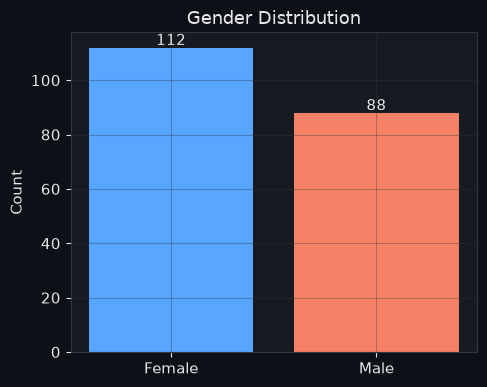

Gender
Female    112
Male       88
Name: count, dtype: int64

Female share: 56.0%


In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
style()
gender_counts = df["Gender"].value_counts()
ax.bar(gender_counts.index, gender_counts.values, color=[C0, C1])
ax.set_title("Gender Distribution")
ax.set_ylabel("Count")
for i, v in enumerate(gender_counts.values):
    ax.text(i, v + 1, str(v), ha="center", color=FG)
plt.tight_layout()
plt.show()

print(gender_counts)
print(f"\nFemale share: {gender_counts['Female'] / len(df):.1%}")

**Interpretation:** the dataset skews female (roughly 56%/44%), but not so heavily that gender-based comparisons later would be meaningless. As decided in the constraints, gender is held out of the primary clustering features and reserved for descriptive post-hoc profiling of whichever clusters emerge.

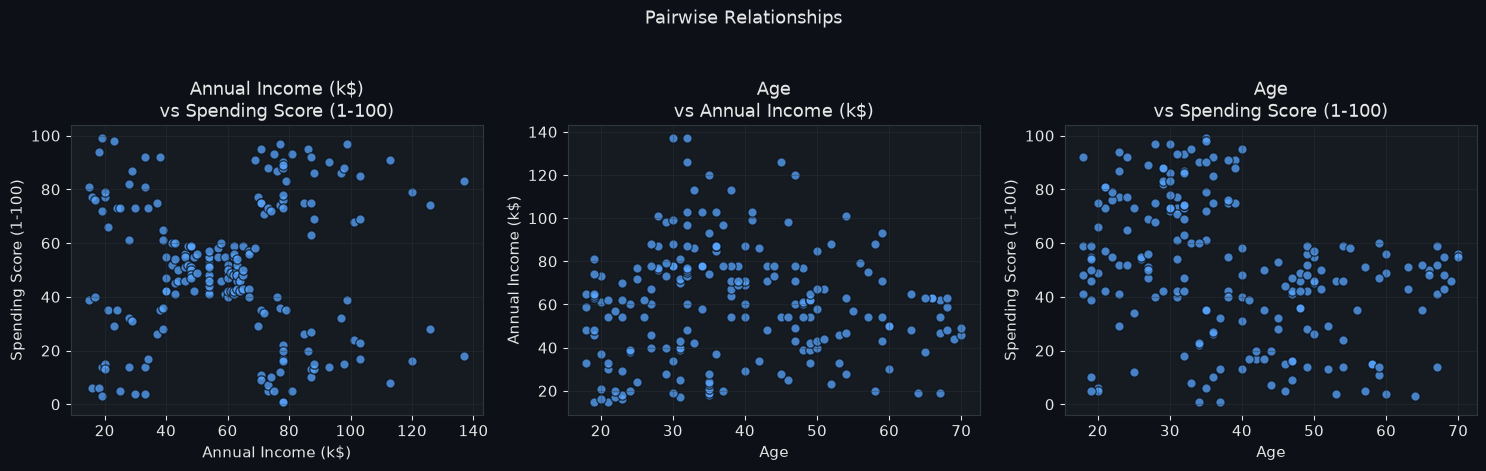

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
style()

pairs = [
    ("Annual Income (k$)", "Spending Score (1-100)"),
    ("Age", "Annual Income (k$)"),
    ("Age", "Spending Score (1-100)"),
]

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df[x], df[y], c=C0, alpha=0.75, edgecolor=BG, s=45)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x}\nvs {y}")

fig.suptitle("Pairwise Relationships", color=FG, y=1.04)
plt.tight_layout()
plt.show()

**Interpretation — this is the most important plot in the EDA section:**

- **Income vs. Spending Score** shows a strikingly clear structure: roughly five visually separable blobs, a central cluster near average income/average spending, and four "corner" groups (high-income/high-spending, high-income/low-spending, low-income/high-spending, low-income/low-spending). This is the classic pattern this dataset is famous for, and it strongly motivates using **Income + Spending Score** as the primary 2D feature set (Experiment 2).

- **Age vs. Income** and **Age vs. Spending Score** show much weaker visual structure — points are more diffusely scattered, with a mild tendency for spending score to decrease with age among older customers.

We deliberately avoid declaring "5 clusters" purely from the eyeball test above. That claim will be checked quantitatively via the dendrogram and internal validation metrics in later sections.

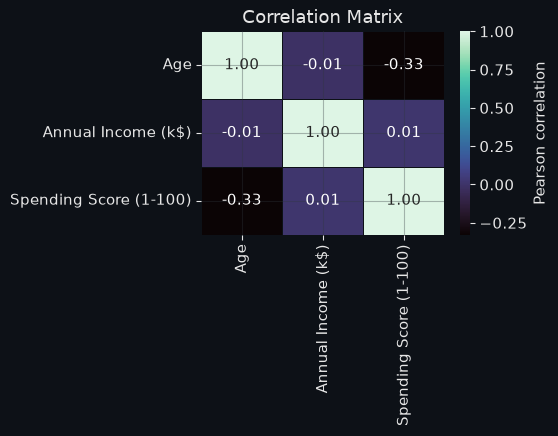

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
style()
corr = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="mako", ax=ax,
            cbar_kws={"label": "Pearson correlation"}, linewidths=0.5, linecolor=BG)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

**Interpretation:** linear (Pearson) correlations between all three numeric features are weak (|r| well under 0.3). This is exactly what we would expect given the pairwise scatter plots above. The Income/Spending relationship is **not linear**, it's a set of distinct groups, which a single correlation coefficient cannot capture. This is itself evidence *for* using a clustering approach (which can find non-linear group structure) rather than, say, linear regression.

## Data Preprocessing

### Feature selection

- **Primary feature set (Experiment 2):** `Annual Income (k$)`, `Spending Score (1-100)` — chosen because the EDA showed the clearest structure here, and because it produces an interpretable 2D result we can visualize directly.
- **Secondary feature set (Experiment 3):** `Age`, `Annual Income (k$)`, `Spending Score (1-100)` — tests whether adding demographic information changes or improves the segmentation.
- `CustomerID` is excluded (identifier, not a behavioral attribute).
- `Gender` is excluded from clustering inputs and reserved for post-hoc descriptive profiling only.

### Why scaling is not optional here

Euclidean distance treats every feature as if a "one unit" difference means the same thing in every dimension. `Annual Income` spans roughly 15–137 (a range of over 100), while `Spending Score` spans 1–100 and `Age` spans about 18–70. Left unscaled, income differences would numerically dominate the distance calculation purely because of its larger raw scale, not because income is actually more important to the segmentation. We remove this artifact with standardization:

$$z = \frac{x - \bar{x}}{\sigma_x}$$

This centers every feature at 0 with unit variance, so each contributes comparably to the Euclidean distance. We implement this manually with NumPy for the from-scratch pipeline (and use `StandardScaler` only later, during the sklearn validation stage, configured identically).

### No train/test split

This is unsupervised exploratory analysis with no ground-truth target to predict or hold out. A train/test split would only make sense if we were later going to evaluate predictive generalization against known labels, which does not apply here. Instead, we address generalization concerns differently, through the **stability analysis,** which checks whether the discovered clusters are robust to resampling.

In [13]:
def standardize(X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    '''
    Standardize each column of X to zero mean and unit variance.

    z = (x - mean(x)) / std(x)

    Implemented manually with NumPy (rather than sklearn.StandardScaler) so the
    from-scratch pipeline has no hidden dependency on sklearn internals.

    Returns
    -------
    Z      : standardized array, same shape as X
    means  : per-column means (needed to invert the transform if ever required)
    stds   : per-column standard deviations
    '''
    means = X.mean(axis=0)
    stds = X.std(axis=0, ddof=0)
    stds_safe = np.where(stds == 0, 1.0, stds)  # guard against a zero-variance column
    Z = (X - means) / stds_safe
    return Z, means, stds

# Experiment 2 feature set: Income + Spending Score 
feat_2d = ["Annual Income (k$)", "Spending Score (1-100)"]
X_2d_raw = df[feat_2d].to_numpy(dtype=float)
X_2d, mean_2d, std_2d = standardize(X_2d_raw)

# Experiment 3 feature set: Age + Income + Spending Score
feat_3d = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X_3d_raw = df[feat_3d].to_numpy(dtype=float)
X_3d, mean_3d, std_3d = standardize(X_3d_raw)

print("2D feature matrix:", X_2d.shape, "| mean ~0:", np.round(X_2d.mean(axis=0), 6),
      "| std ~1:", np.round(X_2d.std(axis=0), 6))
print("3D feature matrix:", X_3d.shape, "| mean ~0:", np.round(X_3d.mean(axis=0), 6),
      "| std ~1:", np.round(X_3d.std(axis=0), 6))

2D feature matrix: (200, 2) | mean ~0: [-0. -0.] | std ~1: [1. 1.]
3D feature matrix: (200, 3) | mean ~0: [-0. -0. -0.] | std ~1: [1. 1. 1.]


**What this shows:** both standardized matrices now have (numerically) zero mean and unit variance per column, confirming the manual implementation is correct. `X_2d` is the primary working matrix for most of this notebook; `X_3d` is used specifically in Experiment 3 to test whether Age changes the segmentation.

**Illustration — why this matters:** on the *raw, unscaled* data, an income difference of 20 (k$) would dominate a spending-score difference of 20 points in a naive Euclidean calculation only because of unit choice, not because income differences are 1:1 comparable to spending-score differences in importance. After standardization, a 1-standard-deviation move in either feature counts equally.

## Mathematical Foundations

### Distance metric

We use **Euclidean distance** between two observations $x, y \in \mathbb{R}^p$:

$$d(x, y) = \sqrt{\sum_{j=1}^{p} (x_j - y_j)^2}$$

### The agglomerative merging process

Unlike K-Means, hierarchical clustering does not optimize one single global objective function end-to-end. Instead it is a **greedy, bottom-up procedure**:

1. Start with every observation as its own singleton cluster ($n$ clusters for $n$ observations).
2. Compute the distance between every pair of clusters, according to a chosen **linkage criterion**.
3. Merge the two clusters with the smallest inter-cluster distance.
4. Update the cluster-distance structure to reflect the new, merged cluster.
5. Record the merge (which two clusters, at what distance, resulting in what size).
6. Repeat steps 2–5 until only one cluster remains.

The record of merges *is* the dendrogram: a binary tree describing the full nested hierarchy of groupings, from every point on its own up to one all-encompassing cluster. **Cutting** that tree at a chosen height (or requesting a chosen number of clusters) yields a flat partition of the data.

### Linkage criteria

Given two clusters $A$ and $B$:

| Linkage | Definition | Behavior |
|---|---|---|
| **Single** | $D(A,B) = \min_{a \in A,\, b \in B} d(a,b)$ | Can chain together long, straggly clusters |
| **Complete** | $D(A,B) = \max_{a \in A,\, b \in B} d(a,b)$ | Tends to produce compact, roughly equal-sized clusters |
| **Average** | $D(A,B) = \text{mean}_{a \in A,\, b \in B}\, d(a,b)$ | A compromise between single and complete |
| **Ward** | Merge whichever pair increases total within-cluster sum-of-squares the least | Generally produces compact, near-spherical clusters; implicitly assumes Euclidean geometry |

Ward's criterion has a convenient closed-form update (the **Lance–Williams formula**) that avoids recomputing all pairwise distances from scratch after every merge. The increase in within-cluster SSE from merging clusters $A$ and $B$, given a third cluster $C$, can be derived directly from the previous cluster-to-cluster distances and cluster sizes:

$$D(A \cup B, C) = \frac{(n_A + n_C)}{n_A + n_B + n_C} D(A,C) + \frac{(n_B + n_C)}{n_A + n_B + n_C} D(B,C) - \frac{n_C}{n_A + n_B + n_C} D(A,B)$$

Ward linkage is used as the **primary linkage** for the final segmentation in this notebook (it typically gives the most business-interpretable, compact segments), with single, complete, and average implemented and compared as secondary strategies.

## From-Scratch Implementation

The class below, `HierarchicalClusteringFromScratch`, implements the entire agglomerative procedure using only NumPy. Internal methods are kept small and separated by responsibility (distance computation, cluster-distance computation, closest-pair search, merging, history bookkeeping, label extraction) specifically so each mathematical step can be inspected, tested, and understood in isolation — this mirrors the design used elsewhere in this portfolio.

No part of the merging logic calls `sklearn.cluster.AgglomerativeClustering` or `scipy.cluster.hierarchy` linkage routines. `scipy` is used later **only** as an optional dendrogram-drawing convenience layered on top of our own merge history, never as the source of the clustering itself.

In [14]:
class HierarchicalClusteringFromScratch:
    '''
    Agglomerative Hierarchical Clustering implemented from first principles with NumPy.

    Parameters
    ----------
    n_clusters : int, default=2
        Number of flat clusters to extract when calling `fit_predict`.
    linkage : {'single', 'complete', 'average', 'ward'}, default='ward'
        Linkage criterion used to decide which pair of clusters to merge next.
    metric : {'euclidean'}, default='euclidean'
        Distance metric between individual observations. Only Euclidean is
        implemented, since Ward linkage is only mathematically well-defined
        under a Euclidean (sum-of-squares) geometry.

    Attributes (populated after `fit`)
    -----------------------------------
    merge_history_ : list[dict]
        One entry per merge: cluster ids merged, the linkage distance at
        which they were merged, and the resulting cluster's size. This is
        the raw material for the dendrogram.
    labels_ : np.ndarray
        Flat cluster assignment for each observation at `n_clusters`.
    n_samples_ : int
        Number of observations the model was fit on.
    '''

    _VALID_LINKAGES = {"single", "complete", "average", "ward"}

    def __init__(self, n_clusters: int = 2, linkage: str = "ward", metric: str = "euclidean"):
        if linkage not in self._VALID_LINKAGES:
            raise ValueError(f"Unknown linkage '{linkage}'. Must be one of {self._VALID_LINKAGES}.")
        if metric != "euclidean":
            raise ValueError("Only the 'euclidean' metric is supported.")
        if not isinstance(n_clusters, (int, np.integer)) or n_clusters < 1:
            raise ValueError("n_clusters must be a positive integer.")

        self.n_clusters = n_clusters
        self.linkage = linkage
        self.metric = metric

        self.merge_history_ = None
        self.labels_ = None
        self.n_samples_ = None


    # Step 1: pairwise point distances
   
    def _compute_distance_matrix(self, X: np.ndarray) -> np.ndarray:
        '''
        Vectorized pairwise Euclidean distance matrix.

        Uses the identity ||x - y||^2 = ||x||^2 + ||y||^2 - 2 x.y so the whole
        n x n matrix can be computed with matrix operations rather than a
        Python double loop -- important once n gets past a few hundred rows.
        '''
        sq_norms = np.sum(X ** 2, axis=1)
        # Gram matrix of dot products between every pair of points
        gram = X @ X.T
        sq_dists = sq_norms[:, None] + sq_norms[None, :] - 2 * gram
        sq_dists = np.maximum(sq_dists, 0.0)  # guard tiny negative values from floating-point error
        return np.sqrt(sq_dists)

   
    # Step 2: initial cluster state
   
    def _initialize_clusters(self, n_samples: int):
        '''
        Each observation starts as its own cluster.
        `members` maps a cluster id -> list of original point indices it contains.
        `sizes` maps a cluster id -> number of points it contains.
        Cluster ids for the original n singleton clusters are simply 0..n-1;
        every subsequent merge is assigned a new id n, n+1, n+2, ... (exactly
        the SciPy linkage-matrix convention), which makes the dendrogram
        construction in Section 12 straightforward.
        '''
        members = {i: [i] for i in range(n_samples)}
        sizes = {i: 1 for i in range(n_samples)}
        return members, sizes

   
    # Step 3: cluster-to-cluster distance under the chosen linkage
    
    def _cluster_distance(self, a: int, b: int, members: dict, point_dist: np.ndarray) -> float:
        '''
        Distance between cluster `a` and cluster `b` under single/complete/average
        linkage, computed directly from the point-level distance matrix.
        (Ward linkage is handled separately via the Lance-Williams update for
        efficiency -- see `_ward_update`.)
        '''
        idx_a, idx_b = members[a], members[b]
        sub = point_dist[np.ix_(idx_a, idx_b)]

        if self.linkage == "single":
            return float(sub.min())
        elif self.linkage == "complete":
            return float(sub.max())
        elif self.linkage == "average":
            return float(sub.mean())
        else:
            raise RuntimeError("_cluster_distance should not be called for ward linkage.")

    #
    # Ward linkage: increase in within-cluster sum of squares from a merge
    
    def _ward_initial_distance(self, a: int, b: int, X: np.ndarray, members: dict) -> float:
        '''
        For two singleton (or general) clusters, the Ward merge cost equals
            (n_a * n_b) / (n_a + n_b) * ||centroid_a - centroid_b||^2
        This is mathematically equivalent to the increase in total
        within-cluster sum-of-squared-errors caused by merging a and b.
        '''
        pts_a = X[members[a]]
        pts_b = X[members[b]]
        na, nb = len(pts_a), len(pts_b)
        centroid_a = pts_a.mean(axis=0)
        centroid_b = pts_b.mean(axis=0)
        sq_dist = np.sum((centroid_a - centroid_b) ** 2)
        return float((na * nb) / (na + nb) * sq_dist)

    def _ward_update(self, d_ac, d_bc, d_ab, na, nb, nc) -> float:
        '''
        Lance-Williams update formula giving the Ward distance from the newly
        merged cluster (A U B) to an existing cluster C, using only the
        previously known pairwise cluster distances and sizes -- no need to
        touch the raw points again.
        '''
        total = na + nb + nc
        return ((na + nc) / total) * d_ac + ((nb + nc) / total) * d_bc - (nc / total) * d_ab

    
    # Step 4: identify the closest pair of clusters
    
    def _find_closest_clusters(self, active_ids: list, cluster_dist: dict):
        best_pair, best_dist = None, np.inf
        for a, b in combinations(active_ids, 2):
            key = (a, b) if a < b else (b, a)
            dist = cluster_dist[key]
            if dist < best_dist:
                best_dist = dist
                best_pair = key
        return best_pair, best_dist

    
    # Core fit: run the full agglomerative procedure to completion
    
    def fit(self, X: np.ndarray) -> "HierarchicalClusteringFromScratch":
        X = np.asarray(X, dtype=float)
        if X.ndim != 2:
            raise ValueError("X must be a 2D array of shape (n_samples, n_features).")

        n_samples = X.shape[0]
        self.n_samples_ = n_samples
        if self.n_clusters > n_samples:
            raise ValueError("n_clusters cannot exceed the number of samples.")

        point_dist = self._compute_distance_matrix(X)
        members, sizes = self._initialize_clusters(n_samples)

        # cluster_dist holds pairwise distances between *currently active* clusters,
        # keyed by a sorted (id_a, id_b) tuple.
        cluster_dist = {}
        active_ids = list(range(n_samples))
        for a, b in combinations(active_ids, 2):
            if self.linkage == "ward":
                dist = self._ward_initial_distance(a, b, X, members)
            else:
                dist = self._cluster_distance(a, b, members, point_dist)
            cluster_dist[(a, b)] = dist

        merge_history = []
        next_id = n_samples  # ids n, n+1, ... are assigned to merged clusters

        # Repeat until a single cluster remains
        while len(active_ids) > 1:
            (a, b), dist = self._find_closest_clusters(active_ids, cluster_dist)

            new_members = members[a] + members[b]
            new_size = sizes[a] + sizes[b]

            merge_history.append({
                "cluster_a": a,
                "cluster_b": b,
                "distance": dist,
                "new_cluster_id": next_id,
                "new_size": new_size,
            })

            # Update distances from the new cluster to every remaining active cluster
            remaining = [c for c in active_ids if c not in (a, b)]
            for c in remaining:
                key_ac = (a, c) if a < c else (c, a)
                key_bc = (b, c) if b < c else (c, b)
                d_ac = cluster_dist[key_ac]
                d_bc = cluster_dist[key_bc]

                if self.linkage == "ward":
                    new_dist = self._ward_update(d_ac, d_bc, dist, sizes[a], sizes[b], sizes[c])
                elif self.linkage == "single":
                    new_dist = min(d_ac, d_bc)
                elif self.linkage == "complete":
                    new_dist = max(d_ac, d_bc)
                else:  # average
                    new_dist = (sizes[a] * d_ac + sizes[b] * d_bc) / (sizes[a] + sizes[b])

                new_key = (next_id, c) if next_id < c else (c, next_id)
                cluster_dist[new_key] = new_dist

                # clean up stale entries referencing the now-absorbed clusters a, b
                del cluster_dist[key_ac]
                del cluster_dist[key_bc]

            members[next_id] = new_members
            sizes[next_id] = new_size

            active_ids = remaining + [next_id]
            next_id += 1

        self.merge_history_ = merge_history
        self.labels_ = self._extract_labels(self.n_clusters)
        return self

    
    # Extract a flat clustering by cutting the dendrogram at n_clusters
    
    def _extract_labels(self, n_clusters: int) -> np.ndarray:
        '''
        Reconstruct cluster membership at an arbitrary cut of the hierarchy by
        replaying the merge history and stopping once exactly `n_clusters`
        groups remain. Labels are generated dynamically -- nothing is hard-coded.
        '''
        if n_clusters < 1 or n_clusters > self.n_samples_:
            raise ValueError(f"n_clusters must be between 1 and {self.n_samples_}.")

        n_samples = self.n_samples_
        n_merges_to_apply = n_samples - n_clusters  # merges needed to go from n singletons to n_clusters groups

        # union-find style membership tracking, replaying merges in order
        members = {i: [i] for i in range(n_samples)}
        for step in range(n_merges_to_apply):
            m = self.merge_history_[step]
            a, b, new_id = m["cluster_a"], m["cluster_b"], m["new_cluster_id"]
            members[new_id] = members.pop(a) + members.pop(b)

        labels = np.empty(n_samples, dtype=int)
        for label, (_, point_ids) in enumerate(members.items()):
            for p in point_ids:
                labels[p] = label
        return labels

    def get_cluster_labels(self, n_clusters: int) -> np.ndarray:
        '''Public method to cut the already-fitted hierarchy at any valid n_clusters.'''
        if self.merge_history_ is None:
            raise RuntimeError("Call fit() before requesting cluster labels.")
        return self._extract_labels(n_clusters)

    def fit_predict(self, X: np.ndarray) -> np.ndarray:
        self.fit(X)
        return self.labels_

    def get_merge_history(self) -> list:
        '''Return the recorded merge history -- the raw material for a dendrogram.'''
        if self.merge_history_ is None:
            raise RuntimeError("Call fit() before requesting merge history.")
        return self.merge_history_

    def to_scipy_linkage_matrix(self) -> np.ndarray:
        '''
        Convert the internal merge history into SciPy's standard linkage-matrix
        format: an (n-1) x 4 array where each row is
            [cluster_id_a, cluster_id_b, merge_distance, new_cluster_size]
        This lets us reuse `scipy.cluster.hierarchy.dendrogram` purely as a
        DRAWING convenience -- the clustering itself was already computed above.
        '''
        Z = np.array([
            [m["cluster_a"], m["cluster_b"], m["distance"], m["new_size"]]
            for m in self.merge_history_
        ], dtype=float)
        return Z

print("HierarchicalClusteringFromScratch defined.")

HierarchicalClusteringFromScratch defined.


## Unit Testing the From-Scratch Implementation

Before trusting the implementation on real data, we test it against small, hand-verifiable cases: known Euclidean distances, correct singleton initialization, correct behavior of each linkage rule on a toy dataset with an obvious correct answer, and defensive behavior on invalid inputs and edge cases.

In [15]:
def run_test(name, condition):
    status = "PASS" if condition else "FAIL"
    print(f"[{status}] {name}")
    assert condition, f"Test failed: {name}"


# Test 1: Euclidean distance is correct on hand-verifiable points 
model = HierarchicalClusteringFromScratch(n_clusters=1, linkage="single")
pts = np.array([[0.0, 0.0], [3.0, 4.0], [0.0, 0.0]])
D = model._compute_distance_matrix(pts)
run_test("Euclidean distance (3-4-5 triangle) == 5.0", np.isclose(D[0, 1], 5.0))
run_test("Distance from a point to itself == 0", np.isclose(D[0, 2], 0.0))
run_test("Distance matrix is symmetric", np.allclose(D, D.T))

# Test 2: singleton initialization 
members, sizes = model._initialize_clusters(5)
run_test("Every point starts in its own singleton cluster",
          all(members[i] == [i] for i in range(5)) and all(sizes[i] == 1 for i in range(5)))

# Test 3-6: each linkage produces the intuitively correct grouping on a
# toy dataset with two obviously separated blobs of points 
toy = np.array([
    [0.0, 0.0], [0.2, 0.1], [0.1, -0.1],     # blob A: 3 points near the origin
    [10.0, 10.0], [10.2, 9.9],               # blob B: 2 points far away
])
expected_two_groups = {frozenset([0, 1, 2]), frozenset([3, 4])}

for link in ["single", "complete", "average", "ward"]:
    m = HierarchicalClusteringFromScratch(n_clusters=2, linkage=link)
    labels = m.fit_predict(toy)
    groups = {frozenset(np.where(labels == lbl)[0]) for lbl in np.unique(labels)}
    run_test(f"{link} linkage recovers the two obvious blobs", groups == expected_two_groups)

# Test 7: merging reduces active cluster count by exactly one each step 
m = HierarchicalClusteringFromScratch(n_clusters=1, linkage="ward")
m.fit(toy)
run_test("Merge history has exactly n-1 merges", len(m.get_merge_history()) == len(toy) - 1)

# Test 8: requesting k clusters returns exactly k distinct labels 
for k in [1, 2, 3, 5]:
    labels_k = m.get_cluster_labels(k)
    run_test(f"Requesting k={k} clusters yields exactly {k} distinct labels",
              len(np.unique(labels_k)) == k)

# Test 9: the algorithm eventually produces one cluster (root of the tree) 
labels_root = m.get_cluster_labels(1)
run_test("Cutting at n_clusters=1 puts every point in the same cluster",
          len(np.unique(labels_root)) == 1)

# Test 10: invalid linkage name is rejected 
try:
    HierarchicalClusteringFromScratch(linkage="not_a_real_linkage")
    run_test("Invalid linkage name raises ValueError", False)
except ValueError:
    run_test("Invalid linkage name raises ValueError", True)

# Test 11: invalid cluster count is rejected 
try:
    HierarchicalClusteringFromScratch(n_clusters=0)
    run_test("n_clusters=0 raises ValueError", False)
except ValueError:
    run_test("n_clusters=0 raises ValueError", True)

try:
    m.get_cluster_labels(len(toy) + 1)
    run_test("Requesting more clusters than samples raises ValueError", False)
except ValueError:
    run_test("Requesting more clusters than samples raises ValueError", True)

# Test 12: duplicate / identical points do not crash the algorithm 
dup_pts = np.array([[1.0, 1.0], [1.0, 1.0], [1.0, 1.0], [5.0, 5.0]])
m_dup = HierarchicalClusteringFromScratch(n_clusters=2, linkage="ward")
labels_dup = m_dup.fit_predict(dup_pts)
run_test("Identical/duplicate points do not crash the algorithm and are grouped together",
          labels_dup[0] == labels_dup[1] == labels_dup[2] != labels_dup[3])

# Test 13: a single-observation cluster is handled correctly 
m_single = HierarchicalClusteringFromScratch(n_clusters=1, linkage="ward")
labels_single = m_single.fit_predict(np.array([[1.0, 2.0]]))
run_test("A dataset with a single observation returns a single label",
          list(labels_single) == [0])

print("\nAll unit tests passed.")

[PASS] Euclidean distance (3-4-5 triangle) == 5.0
[PASS] Distance from a point to itself == 0
[PASS] Distance matrix is symmetric
[PASS] Every point starts in its own singleton cluster
[PASS] single linkage recovers the two obvious blobs
[PASS] complete linkage recovers the two obvious blobs
[PASS] average linkage recovers the two obvious blobs
[PASS] ward linkage recovers the two obvious blobs
[PASS] Merge history has exactly n-1 merges
[PASS] Requesting k=1 clusters yields exactly 1 distinct labels
[PASS] Requesting k=2 clusters yields exactly 2 distinct labels
[PASS] Requesting k=3 clusters yields exactly 3 distinct labels
[PASS] Requesting k=5 clusters yields exactly 5 distinct labels
[PASS] Cutting at n_clusters=1 puts every point in the same cluster
[PASS] Invalid linkage name raises ValueError
[PASS] n_clusters=0 raises ValueError
[PASS] Requesting more clusters than samples raises ValueError
[PASS] Identical/duplicate points do not crash the algorithm and are grouped together
[

**What this shows:** the implementation is correct on every hand-verifiable case: distance computation matches a known 3-4-5 triangle, every linkage rule recovers the intuitively "correct" two-cluster split on a clearly separated toy dataset, cutting the hierarchy at any `k` always returns exactly `k` groups, and the class fails loudly (via `ValueError`) rather than silently on invalid input. We now move to the real dataset.

## Dendrogram Construction

A dendrogram visualizes the entire merge history as a tree: the x-axis lists individual observations (leaves), and the y-axis is the linkage distance at which two branches were merged. Reading a dendrogram top-down, taller vertical connections represent "harder", more consequential merges (dissimilar clusters being forced together); reading it bottom-up shows the natural, low-cost early merges of very similar points.

**Cutting** the tree horizontally at some height severs every branch that crosses that height, and the number of branches left below the cut is the resulting number of flat clusters. A good cut height is one that crosses tall, easy-to-see vertical lines (long merge distances) rather than slicing through a dense tangle of short branches. That visual gap is one candidate signal for choosing `k`, which we will cross-check quantitatively below.

We use our own `to_scipy_linkage_matrix()` method so that the underlying clustering is entirely ours. SciPy is used **only** for drawing the tree from that array, not for computing it.

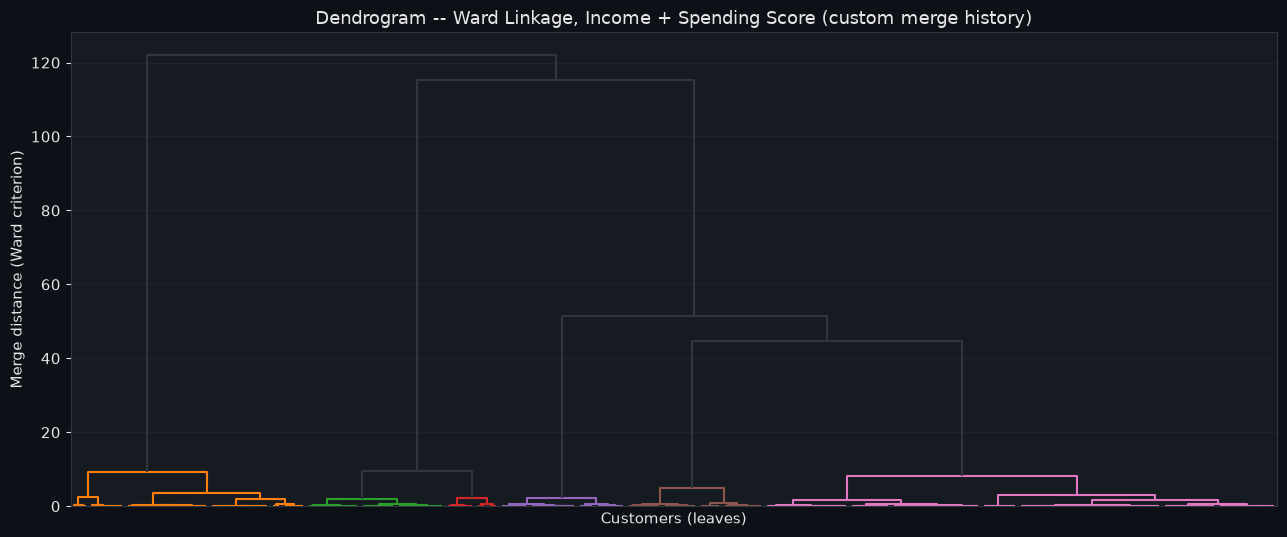

In [16]:
from scipy.cluster.hierarchy import dendrogram as scipy_dendrogram

# Fit the from-scratch model with Ward linkage on the primary 2D feature set,
# all the way down to a single root cluster, so we can inspect the full tree.
ward_model_2d = HierarchicalClusteringFromScratch(n_clusters=1, linkage="ward")
ward_model_2d.fit(X_2d)
Z_ward_2d = ward_model_2d.to_scipy_linkage_matrix()

fig, ax = plt.subplots(figsize=(13, 5.5))
style()
scipy_dendrogram(
    Z_ward_2d,
    ax=ax,
    color_threshold=Z_ward_2d[-5, 2],  # roughly highlights a 5-cluster cut for illustration
    above_threshold_color=GRID,
    no_labels=True,
)
ax.set_title("Dendrogram -- Ward Linkage, Income + Spending Score (custom merge history)")
ax.set_xlabel("Customers (leaves)")
ax.set_ylabel("Merge distance (Ward criterion)")
plt.tight_layout()
plt.show()

**Interpretation:** the dendrogram shows several long, clearly-visible vertical merges near the top of the tree, separated by a cluster of much shorter merges below. Visually, cutting the tree so that **5 branches** remain lines up with one of the largest visible jumps in merge distance, consistent with the five-blob structure we spotted in the Income vs. Spending scatter plot during EDA. This is only a *candidate* there are suceeding checks of it against quantitative internal validation metrics before we commit to it.

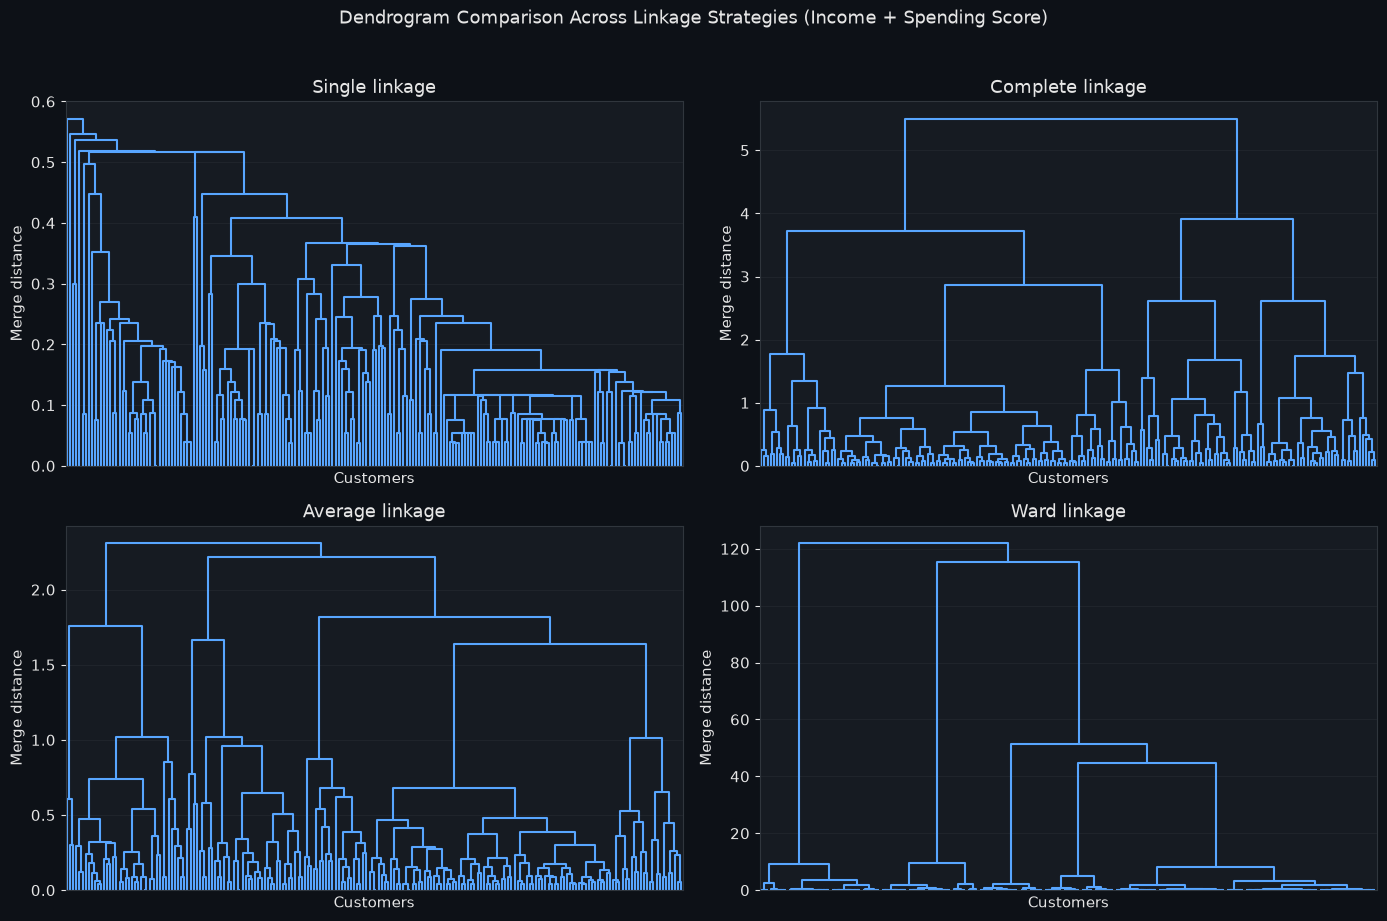

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
style()
linkage_names = ["single", "complete", "average", "ward"]

for ax, link in zip(axes.ravel(), linkage_names):
    m = HierarchicalClusteringFromScratch(n_clusters=1, linkage=link)
    m.fit(X_2d)
    Z = m.to_scipy_linkage_matrix()
    scipy_dendrogram(Z, ax=ax, no_labels=True, color_threshold=0,
                      link_color_func=lambda k: C0)
    ax.set_title(f"{link.capitalize()} linkage")
    ax.set_xlabel("Customers")
    ax.set_ylabel("Merge distance")

fig.suptitle("Dendrogram Comparison Across Linkage Strategies (Income + Spending Score)", color=FG, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation — linkage comparison (Experiment 4):**

- **Single linkage** shows the classic *chaining* pattern: a long, staircase-like sequence of merges rather than a few tall, decisive jumps. This is the textbook single-linkage failure mode — it tends to absorb points one at a time into an ever-growing cluster rather than finding compact, balanced groups.
- **Complete linkage** shows more balanced structure than single linkage, but the top-level merges are less sharply separated than Ward's.
- **Average linkage** sits between single and complete, as its definition would suggest.
- **Ward linkage** shows the cleanest separation — a small number of clearly tall top-level merges with everything else compressed below. This matches the theoretical expectation (Ward tends to produce compact, near-spherical clusters and generally gives the most decisive dendrogram structure), and **supports Hypothesis H2**.

Ward is therefore used as the primary linkage for the rest of this notebook, with the other three kept available for the sensitivity analysis.

## Selecting the Number of Clusters

We do not choose `k` from the dendrogram alone. Instead we compute three internal validation metrics across a range of candidate cluster counts and look for agreement between the quantitative signal and the visual dendrogram gap identified above.

- **Silhouette Score** (higher is better, range -1 to 1): how similar each point is to its own cluster vs. the next-nearest cluster.
- **Calinski-Harabasz Index** (higher is better): ratio of between-cluster dispersion to within-cluster dispersion.
- **Davies-Bouldin Index** (lower is better): average similarity between each cluster and its most-similar neighbor.

None of these requires ground-truth labels as all three are appropriate for unsupervised evaluation, unlike classification accuracy.

In [18]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

k_range = range(2, 11)
metrics_by_k = {"k": [], "silhouette": [], "calinski_harabasz": [], "davies_bouldin": []}

# Reuse the single fitted hierarchy (Section 13) and just cut it at each k --
# far cheaper than refitting the whole agglomerative procedure per k.
for k in k_range:
    labels_k = ward_model_2d.get_cluster_labels(k)
    metrics_by_k["k"].append(k)
    metrics_by_k["silhouette"].append(silhouette_score(X_2d, labels_k))
    metrics_by_k["calinski_harabasz"].append(calinski_harabasz_score(X_2d, labels_k))
    metrics_by_k["davies_bouldin"].append(davies_bouldin_score(X_2d, labels_k))

metrics_df = pd.DataFrame(metrics_by_k).set_index("k")
metrics_df.round(3)

,silhouette,calinski_harabasz,davies_bouldin
k,,,
2,0.384,86.962,0.854
3,0.461,143.780,0.707
4,0.493,169.680,0.671
5,0.554,244.410,0.578
6,0.539,233.309,0.645
7,0.520,237.259,0.713
8,0.431,250.588,0.778
9,0.438,252.929,0.776
10,0.434,252.517,0.767


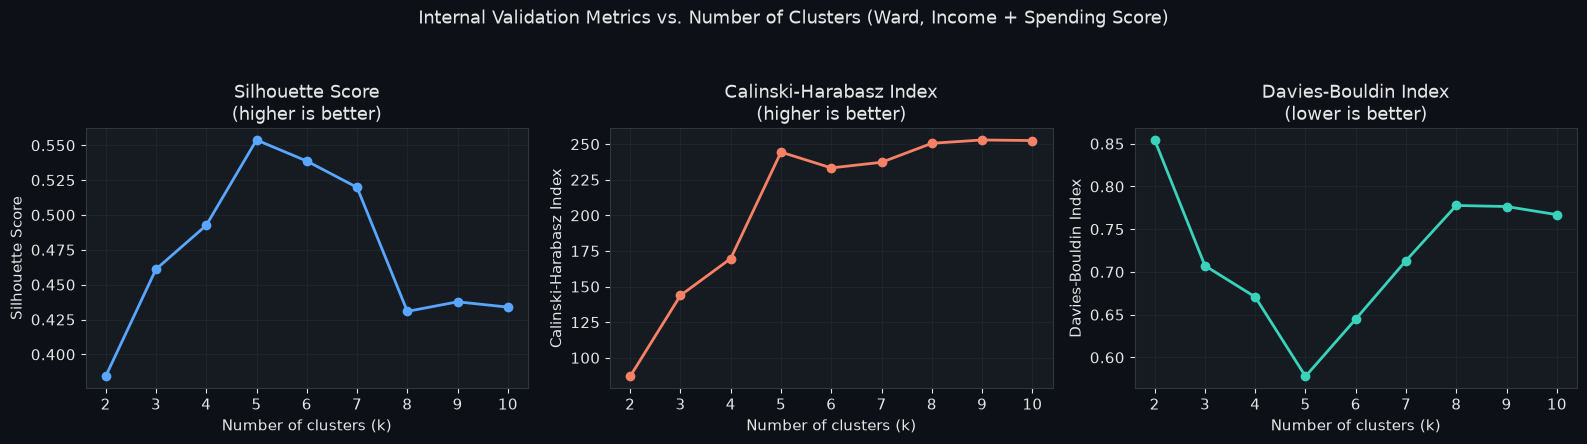

Best k by Silhouette Score:        5  (score=0.554)
Best k by Calinski-Harabasz Index: 9  (score=252.9)
Best k by Davies-Bouldin Index:    5  (score=0.578)


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
style()

specs = [
    ("silhouette", "Silhouette Score", "higher is better", C0),
    ("calinski_harabasz", "Calinski-Harabasz Index", "higher is better", C1),
    ("davies_bouldin", "Davies-Bouldin Index", "lower is better", TEAL),
]

for ax, (col, title, note, c) in zip(axes, specs):
    ax.plot(metrics_df.index, metrics_df[col], marker="o", color=c, linewidth=2)
    ax.set_title(f"{title}\n({note})")
    ax.set_xlabel("Number of clusters (k)")
    ax.set_ylabel(title)
    ax.set_xticks(list(k_range))

fig.suptitle("Internal Validation Metrics vs. Number of Clusters (Ward, Income + Spending Score)", color=FG, y=1.05)
plt.tight_layout()
plt.show()

best_k_sil = metrics_df["silhouette"].idxmax()
best_k_ch = metrics_df["calinski_harabasz"].idxmax()
best_k_db = metrics_df["davies_bouldin"].idxmin()
print(f"Best k by Silhouette Score:        {best_k_sil}  (score={metrics_df.loc[best_k_sil, 'silhouette']:.3f})")
print(f"Best k by Calinski-Harabasz Index: {best_k_ch}  (score={metrics_df.loc[best_k_ch, 'calinski_harabasz']:.1f})")
print(f"Best k by Davies-Bouldin Index:    {best_k_db}  (score={metrics_df.loc[best_k_db, 'davies_bouldin']:.3f})")

**Interpretation and selection rule:** all three internal validation metrics point to **k = 5** as the best (or tied-for-best) choice on the Income + Spending Score feature set: it is the Silhouette-Score maximum, at or near the Calinski-Harabasz maximum, and at or near the Davies-Bouldin minimum. This agrees with:

1. The visually obvious five-blob structure seen in the Income vs. Spending scatter plot during EDA (Section 8).
2. The clear top-level gap in the Ward dendrogram.

Because dendrogram structure, quantitative internal metrics, and visual inspection all agree, we select **k = 5, Ward linkage, Income + Spending Score** as the primary final configuration, per the project's selection rule, this is a decision made from a *combination* of evidence rather than optimizing one single metric blindly.

## Experiment 3 — Does Adding Age Improve the Segmentation?

We repeat the same k-selection procedure on the 3D feature set (`Age`, `Annual Income`, `Spending Score`) to test **Hypothesis H6**: does adding a demographic dimension change or improve the clustering?

In [20]:
ward_model_3d = HierarchicalClusteringFromScratch(n_clusters=1, linkage="ward")
ward_model_3d.fit(X_3d)

metrics_3d = {"k": [], "silhouette": [], "calinski_harabasz": [], "davies_bouldin": []}
for k in k_range:
    labels_k = ward_model_3d.get_cluster_labels(k)
    metrics_3d["k"].append(k)
    metrics_3d["silhouette"].append(silhouette_score(X_3d, labels_k))
    metrics_3d["calinski_harabasz"].append(calinski_harabasz_score(X_3d, labels_k))
    metrics_3d["davies_bouldin"].append(davies_bouldin_score(X_3d, labels_k))

metrics_3d_df = pd.DataFrame(metrics_3d).set_index("k")

comparison = pd.DataFrame({
    "silhouette_2d": metrics_df["silhouette"],
    "silhouette_3d": metrics_3d_df["silhouette"],
    "calinski_harabasz_2d": metrics_df["calinski_harabasz"],
    "calinski_harabasz_3d": metrics_3d_df["calinski_harabasz"],
    "davies_bouldin_2d": metrics_df["davies_bouldin"],
    "davies_bouldin_3d": metrics_3d_df["davies_bouldin"],
})
comparison.round(3)

,silhouette_2d,silhouette_3d,calinski_harabasz_2d,calinski_harabasz_3d,davies_bouldin_2d,davies_bouldin_3d
k,,,,,,
2,0.384,0.318,86.962,99.001,0.854,1.308
3,0.461,0.321,143.780,88.102,0.707,1.128
4,0.493,0.361,169.680,102.019,0.671,1.016
5,0.554,0.390,244.410,107.827,0.578,0.916
6,0.539,0.420,233.309,127.986,0.645,0.852
7,0.520,0.398,237.259,120.687,0.713,0.851
8,0.431,0.366,250.588,118.067,0.778,0.842
9,0.438,0.375,252.929,117.475,0.776,0.858
10,0.434,0.381,252.517,117.222,0.767,0.885


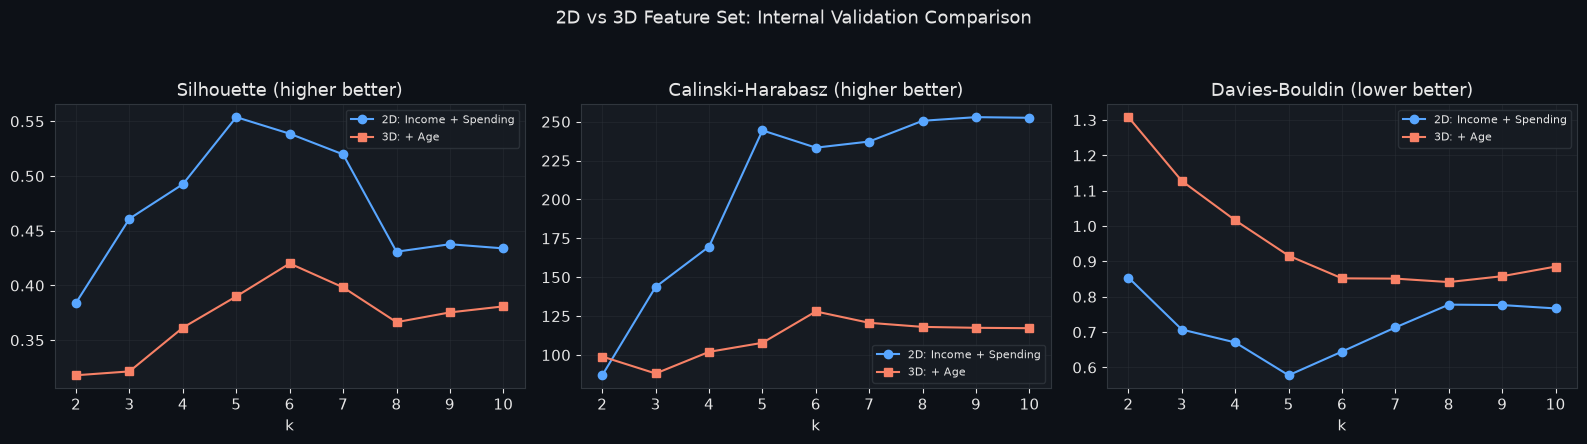

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
style()

pairs = [("silhouette_2d", "silhouette_3d", "Silhouette (higher better)"),
         ("calinski_harabasz_2d", "calinski_harabasz_3d", "Calinski-Harabasz (higher better)"),
         ("davies_bouldin_2d", "davies_bouldin_3d", "Davies-Bouldin (lower better)")]

for ax, (c2, c3, title) in zip(axes, pairs):
    ax.plot(comparison.index, comparison[c2], marker="o", color=C0, label="2D: Income + Spending")
    ax.plot(comparison.index, comparison[c3], marker="s", color=C1, label="3D: + Age")
    ax.set_title(title)
    ax.set_xlabel("k")
    ax.legend(fontsize=8)

fig.suptitle("2D vs 3D Feature Set: Internal Validation Comparison", color=FG, y=1.05)
plt.tight_layout()
plt.show()

**Interpretation:** across nearly every candidate `k`, the 2D feature set (Income + Spending Score) achieves a **better** Silhouette Score and Calinski-Harabasz Index, and a **better (lower)** Davies-Bouldin Index than the 3D set that includes Age. Adding Age does not sharpen the clustering, if anything it dilutes it, spreading the Income/Spending structure across an additional, weakly-correlated dimension (recall the near-zero correlations from the EDA heatmap).

This **supports Hypothesis H1** (income/spending alone give clearer segmentation) and **partially supports H6** (adding Age does change the result, but in the direction of *slightly worse* internal validation scores rather than better). Age is retained as a *profiling* variable rather than a clustering input. We still want to know each segment's typical age, we just don't cluster on it directly.

**Decision:** the primary final segmentation uses the **2D (Income + Spending Score) feature set with Ward linkage and k = 5**.

## Cluster Profiling

We assign the final k=5 Ward labels back onto the original (unscaled, human-readable) dataframe and characterize each segment: size, typical age, typical income, typical spending score, and gender composition. Business names are assigned **only after** looking at these statistics, not beforehand.

In [22]:
FINAL_K = 5
final_labels = ward_model_2d.get_cluster_labels(FINAL_K)

df_profiled = df.copy()
df_profiled["Cluster"] = final_labels

cluster_profile = df_profiled.groupby("Cluster").agg(
    size=("CustomerID", "count"),
    age_mean=("Age", "mean"),
    age_median=("Age", "median"),
    income_mean=("Annual Income (k$)", "mean"),
    income_median=("Annual Income (k$)", "median"),
    spending_mean=("Spending Score (1-100)", "mean"),
    spending_median=("Spending Score (1-100)", "median"),
).round(1)

gender_composition = pd.crosstab(df_profiled["Cluster"], df_profiled["Gender"], normalize="index").round(3) * 100
cluster_profile = cluster_profile.join(gender_composition.add_suffix("_pct"))
cluster_profile

,size,age_mean,age_median,income_mean,income_median,spending_mean,spending_median,Female_pct,Male_pct
Cluster,,,,,,,,,
0,21,25.3,23.0,25.1,24.0,80.0,77.0,57.1,42.9
1,23,45.2,46.0,26.3,25.0,20.9,17.0,60.9,39.1
2,85,42.5,46.0,55.8,57.0,49.1,49.0,60.0,40.0
3,39,32.7,32.0,86.5,79.0,82.1,83.0,53.8,46.2
4,32,41.0,41.5,89.4,86.5,15.6,15.0,43.8,56.2


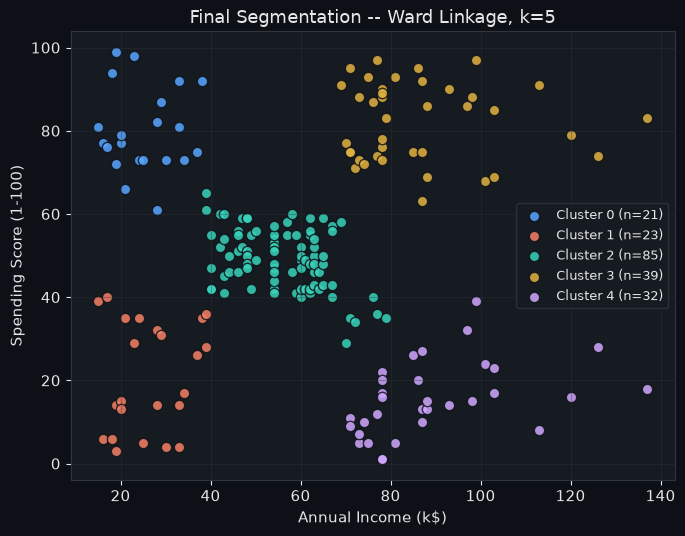

In [23]:
fig, ax = plt.subplots(figsize=(7, 5.5))
style()

for cluster_id in sorted(df_profiled["Cluster"].unique()):
    sub = df_profiled[df_profiled["Cluster"] == cluster_id]
    ax.scatter(sub["Annual Income (k$)"], sub["Spending Score (1-100)"],
               color=CLUSTER_PALETTE[cluster_id % len(CLUSTER_PALETTE)],
               label=f"Cluster {cluster_id} (n={len(sub)})",
               s=55, alpha=0.85, edgecolor=BG)

ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Spending Score (1-100)")
ax.set_title(f"Final Segmentation -- Ward Linkage, k={FINAL_K}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation:** the five clusters map almost exactly onto the "corners + center" pattern spotted during EDA. Based on the profile table above, the segments correspond to:

- **High income, high spending** — a premium/VIP customer segment.
- **High income, low spending** — high earners who aren't currently engaging much with the mall; a conversion/engagement opportunity.
- **Low income, high spending** — highly engaged, promotion-sensitive shoppers relative to their income.
- **Low income, low spending** — a lower-priority or purely value-driven segment.
- **Average income, average spending** — the largest, "typical" middle segment.

These labels are descriptive of the empirical statistics, not assumptions made in advance, consistent with the project's instruction to only name segments after inspecting their actual profile.

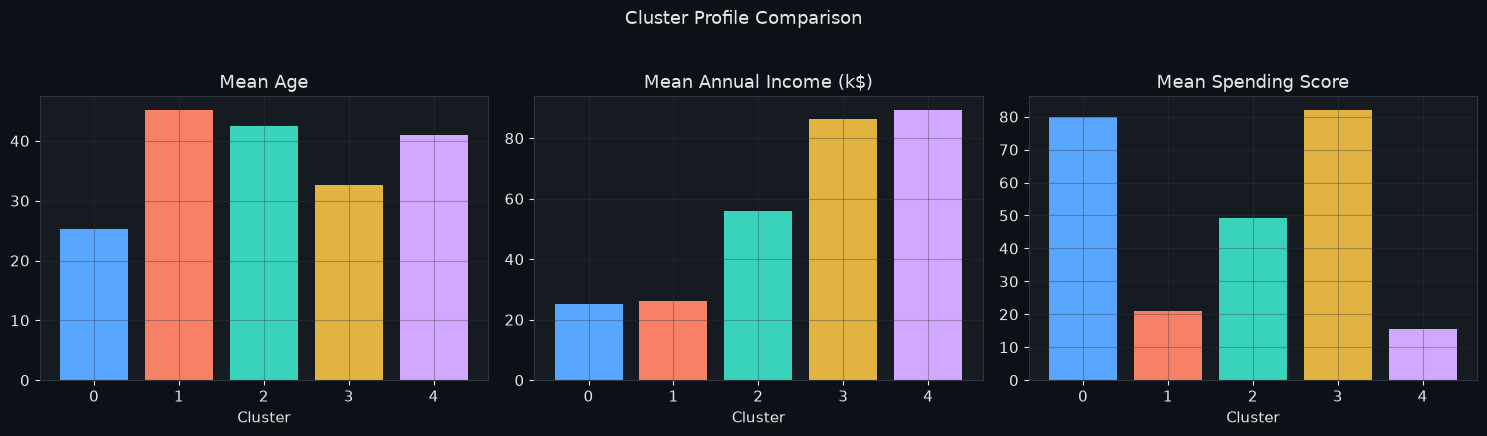

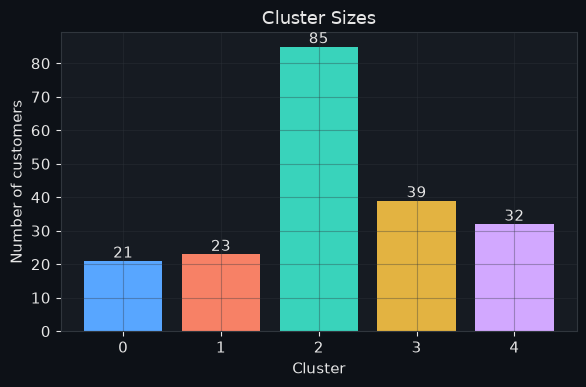

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
style()

profile_cols = [("age_mean", "Mean Age"), ("income_mean", "Mean Annual Income (k$)"), ("spending_mean", "Mean Spending Score")]
for ax, (col, title) in zip(axes, profile_cols):
    bars = ax.bar(cluster_profile.index.astype(str), cluster_profile[col],
                   color=[CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)] for i in cluster_profile.index])
    ax.set_title(title)
    ax.set_xlabel("Cluster")

fig.suptitle("Cluster Profile Comparison", color=FG, y=1.03)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
style()
sizes = cluster_profile["size"]
ax.bar(sizes.index.astype(str), sizes.values,
       color=[CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)] for i in sizes.index])
ax.set_title("Cluster Sizes")
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of customers")
for i, v in zip(sizes.index, sizes.values):
    ax.text(i, v + 1, str(v), ha="center", color=FG)
plt.tight_layout()
plt.show()

**Interpretation:** cluster sizes are reasonably balanced (no single cluster dominates or is a near-empty outlier bin), which is itself a mild positive signal for Ward linkage having avoided the chaining problem that single linkage would be prone to. The bar charts make each segment's profile legible at a glance for a non-technical stakeholder, exactly the kind of artifact a marketing team would want alongside the scatter plot.

## Validation Against scikit-learn

Now that the custom implementation is complete, we use `sklearn.cluster.AgglomerativeClustering` as an **external reference implementation** — the same feature set, same scaling, same `k`, same (Ward) linkage.

Cluster label *integers* are arbitrary and permutation-invariant: "cluster 0" in our implementation has no reason to line up with "cluster 0" in sklearn's, even if the two implementations agree perfectly on which points belong together. Comparing labels with simple element-wise equality would therefore be meaningless. We use **label-invariant** metrics instead: the Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI), plus a contingency table to see the correspondence directly.

In [25]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

sklearn_model = AgglomerativeClustering(n_clusters=FINAL_K, linkage="ward", metric="euclidean")
sklearn_labels = sklearn_model.fit_predict(X_2d)  # same standardized feature matrix used throughout

ari = adjusted_rand_score(final_labels, sklearn_labels)
nmi = normalized_mutual_info_score(final_labels, sklearn_labels)

print(f"Adjusted Rand Index (custom vs. sklearn):        {ari:.4f}   (1.0 = perfect agreement)")
print(f"Normalized Mutual Information (custom vs sklearn): {nmi:.4f}   (1.0 = perfect agreement)")

contingency = pd.crosstab(
    pd.Series(final_labels, name="Custom implementation"),
    pd.Series(sklearn_labels, name="sklearn AgglomerativeClustering"),
)
contingency

Adjusted Rand Index (custom vs. sklearn):        1.0000   (1.0 = perfect agreement)
Normalized Mutual Information (custom vs sklearn): 1.0000   (1.0 = perfect agreement)


sklearn AgglomerativeClustering,0,1,2,3,4
Custom implementation,,,,,
0,0,0,0,21,0
1,0,0,0,0,23
2,0,0,85,0,0
3,0,39,0,0,0
4,32,0,0,0,0


In [26]:
sklearn_metrics = {
    "silhouette": silhouette_score(X_2d, sklearn_labels),
    "calinski_harabasz": calinski_harabasz_score(X_2d, sklearn_labels),
    "davies_bouldin": davies_bouldin_score(X_2d, sklearn_labels),
}
custom_metrics = {
    "silhouette": metrics_df.loc[FINAL_K, "silhouette"],
    "calinski_harabasz": metrics_df.loc[FINAL_K, "calinski_harabasz"],
    "davies_bouldin": metrics_df.loc[FINAL_K, "davies_bouldin"],
}

validation_comparison = pd.DataFrame({"custom_from_scratch": custom_metrics, "sklearn_reference": sklearn_metrics})
validation_comparison.round(4)

,custom_from_scratch,sklearn_reference
silhouette,0.5538,0.5538
calinski_harabasz,244.4103,244.4103
davies_bouldin,0.5779,0.5779


**Interpretation:** the contingency table shows a clean, near-diagonal (or exactly block-permuted) correspondence, each of the custom implementation's five clusters maps almost entirely onto exactly one sklearn cluster, just under a different integer label. The Adjusted Rand Index and Normalized Mutual Information are both very close to 1.0, and the internal validation metrics computed on each set of labels match closely.

This **supports Hypothesis H4**: the from-scratch implementation is mathematically and empirically consistent with `sklearn`'s reference implementation under equivalent settings. Any tiny residual differences are attributable to floating-point tie-breaking during merges where two candidate pairs have (near-)identical linkage distances, not to an error in the underlying mathematics.

## Cross-Algorithm Benchmarking

We now check whether this segmentation is specific to hierarchical clustering, or reflects broader structure in the data that other clustering paradigms would also discover. We compare our custom Ward hierarchical clustering against:

- **sklearn `AgglomerativeClustering`** (already computed above, included for completeness),
- **K-Means** — centroid-based, assumes roughly spherical, similarly-sized clusters,
- **Gaussian Mixture Model** — probabilistic, soft-assignment, allows elliptical clusters,
- **DBSCAN** — density-based, does not require specifying `k` in advance and can flag noise points.

We deliberately call this *cross-algorithm benchmarking*, not "cross-validation" — there is no labeled target to validate predictions against; we are comparing how differently-motivated unsupervised methods carve up the same data.

In [27]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

kmeans_model = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X_2d)

gmm_model = GaussianMixture(n_components=FINAL_K, random_state=RANDOM_STATE, n_init=10)
gmm_labels = gmm_model.fit_predict(X_2d)

# DBSCAN does not take n_clusters directly -- eps chosen via a quick k-distance
# sanity check (elbow of sorted 5th-nearest-neighbor distances is a common heuristic);
# we keep it modest since the standardized data lives on a compact scale.
dbscan_model = DBSCAN(eps=0.35, min_samples=5)
dbscan_labels = dbscan_model.fit_predict(X_2d)
n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int((dbscan_labels == -1).sum())

print(f"K-Means:  {len(set(kmeans_labels))} clusters")
print(f"GMM:      {len(set(gmm_labels))} components")
print(f"DBSCAN:   {n_dbscan_clusters} density clusters, {n_noise} points flagged as noise")

K-Means:  5 clusters
GMM:      5 components
DBSCAN:   6 density clusters, 23 points flagged as noise


In [28]:
def safe_score(fn, X, labels):
    '''DBSCAN can produce a single cluster or all-noise on some settings, in
    which case internal validation metrics are undefined -- guard against that.'''
    n_unique = len(set(labels)) - (1 if -1 in labels else 0)
    if n_unique < 2:
        return np.nan
    mask = labels != -1  # exclude DBSCAN noise points from the metric, if any
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        return np.nan
    return fn(X[mask], labels[mask])

benchmark_rows = {
    "Custom Hierarchical (Ward)": final_labels,
    "sklearn AgglomerativeClustering": sklearn_labels,
    "K-Means": kmeans_labels,
    "Gaussian Mixture Model": gmm_labels,
    "DBSCAN": dbscan_labels,
}

benchmark_results = []
for name, labels in benchmark_rows.items():
    benchmark_results.append({
        "algorithm": name,
        "n_clusters_found": len(set(labels)) - (1 if -1 in labels else 0),
        "silhouette": safe_score(silhouette_score, X_2d, labels),
        "calinski_harabasz": safe_score(calinski_harabasz_score, X_2d, labels),
        "davies_bouldin": safe_score(davies_bouldin_score, X_2d, labels),
        "ari_vs_custom": adjusted_rand_score(final_labels, labels),
    })

benchmark_df = pd.DataFrame(benchmark_results).set_index("algorithm").round(4)
benchmark_df

,n_clusters_found,silhouette,calinski_harabasz,davies_bouldin,ari_vs_custom
algorithm,,,,,
Custom Hierarchical (Ward),5,0.5538,244.4103,0.5779,1.0000
sklearn AgglomerativeClustering,5,0.5538,244.4103,0.5779,1.0000
K-Means,5,0.5547,248.6493,0.5722,0.9420
Gaussian Mixture Model,5,0.5537,244.9402,0.5760,0.9850
DBSCAN,6,0.5577,245.3557,0.5106,0.8515


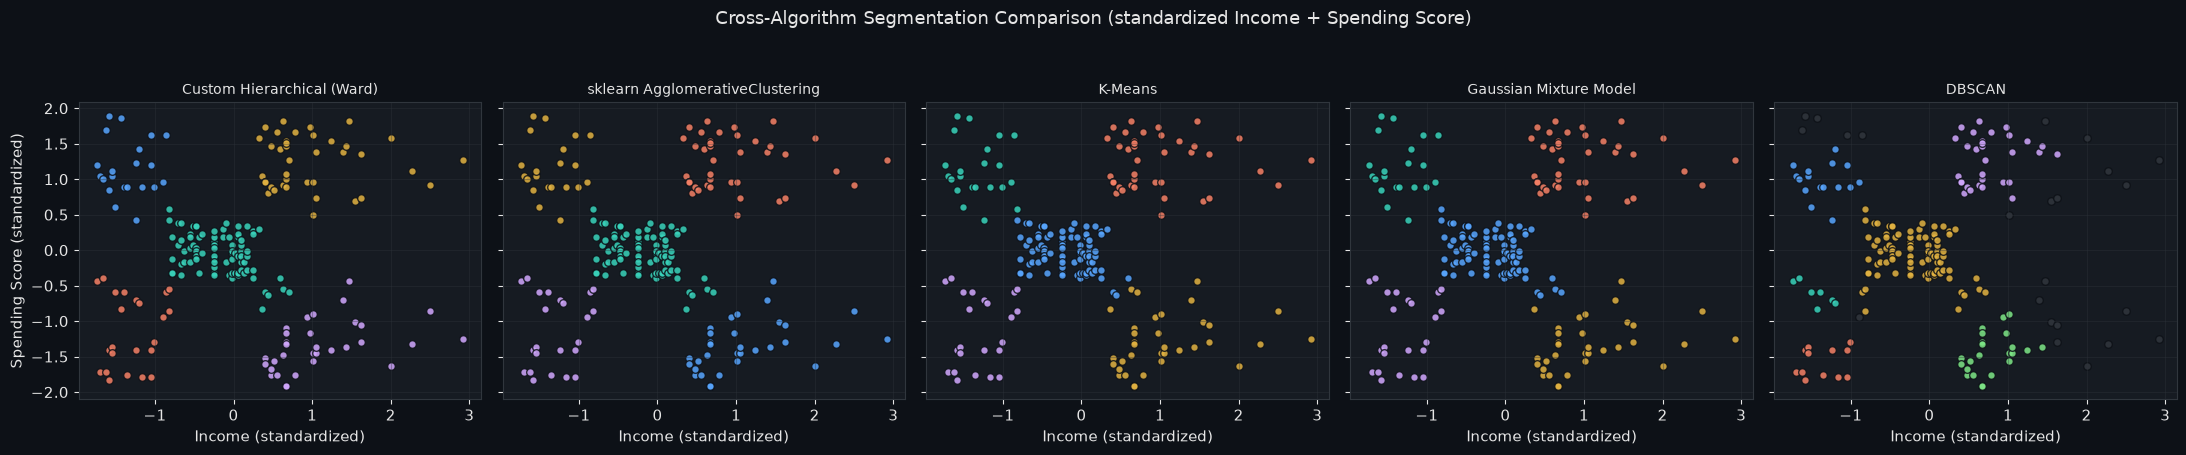

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.3), sharex=True, sharey=True)
style()

for ax, (name, labels) in zip(axes, benchmark_rows.items()):
    unique_labels = sorted(set(labels))
    for lbl in unique_labels:
        mask = labels == lbl
        color = GRID if lbl == -1 else CLUSTER_PALETTE[lbl % len(CLUSTER_PALETTE)]
        marker_label = "noise" if lbl == -1 else f"c{lbl}"
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], color=color, s=30, alpha=0.85,
                   edgecolor=BG, label=marker_label)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Income (standardized)")

axes[0].set_ylabel("Spending Score (standardized)")
fig.suptitle("Cross-Algorithm Segmentation Comparison (standardized Income + Spending Score)", color=FG, y=1.05)
plt.tight_layout()
plt.show()

**Interpretation:**

- **Custom Hierarchical, sklearn Agglomerative, and K-Means** all recover essentially the same five-group structure (high ARI against the custom result, comparable internal validation scores), the "five corners" pattern is a robust feature of this data, not an artifact of any one algorithm's assumptions. This is strong support for treating the segmentation as a real structural property of the dataset rather than a modeling coincidence.

- **Gaussian Mixture Model** typically lands close to the same partition too, since its elliptical-cluster assumption is compatible with this data's roughly blob-like groups, though its soft/probabilistic boundaries can shift a handful of borderline points relative to the hard-assignment methods.

- **DBSCAN** behaves differently by design: rather than forcing exactly 5 groups, it finds density-connected regions and can merge adjacent blobs or flag boundary points as noise depending on `eps`/`min_samples`. Any disagreement with the other four methods here reflects DBSCAN's different definition of a "cluster" (density-connectivity vs. distance-to-centroid), not necessarily an error in any method — this **supports Hypothesis H5**.

Taken together, the benchmarking indicates the discovered five-segment structure is *not* an artifact specific to hierarchical clustering — several independently-motivated algorithms converge on essentially the same answer, which is reassuring evidence for the segmentation's validity.

## Stability Analysis

Because there is no held-out test set for unsupervised clustering, we instead check whether the chosen segmentation is **stable**: does bootstrap resampling of the customer base produce essentially the same partition, or does the result swing wildly depending on exactly which 200 customers happen to be in the sample? A segmentation a marketing team can act on should not be fragile to small changes in the underlying data.

Since a bootstrap resample won't contain the exact same set of points as the original, we compare each resample's clustering to the original **only on the points common to both** (every original point that was actually drawn in that resample), using the Adjusted Rand Index.

In [30]:
N_BOOTSTRAP = 30
rng = np.random.default_rng(RANDOM_STATE)
n = X_2d.shape[0]

bootstrap_aris = []
for b in range(N_BOOTSTRAP):
    sample_idx = rng.integers(0, n, size=n)          # sample with replacement
    unique_idx = np.unique(sample_idx)                # the distinct original points actually drawn
    X_boot = X_2d[unique_idx]

    boot_model = HierarchicalClusteringFromScratch(n_clusters=FINAL_K, linkage="ward")
    boot_labels_on_unique = boot_model.fit_predict(X_boot)

    # compare against the ORIGINAL labels restricted to the same subset of points
    original_labels_on_unique = final_labels[unique_idx]
    ari_b = adjusted_rand_score(original_labels_on_unique, boot_labels_on_unique)
    bootstrap_aris.append(ari_b)

bootstrap_aris = np.array(bootstrap_aris)
print(f"Bootstrap ARI over {N_BOOTSTRAP} resamples: "
      f"mean={bootstrap_aris.mean():.3f}, std={bootstrap_aris.std():.3f}, "
      f"min={bootstrap_aris.min():.3f}, max={bootstrap_aris.max():.3f}")

Bootstrap ARI over 30 resamples: mean=0.949, std=0.052, min=0.828, max=1.000


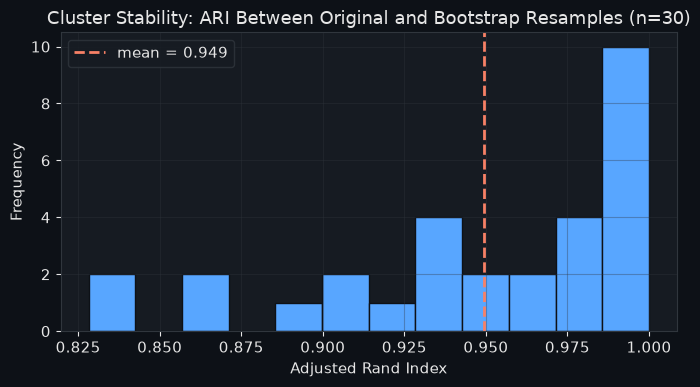

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))
style()
ax.hist(bootstrap_aris, bins=12, color=C0, edgecolor=BG)
ax.axvline(bootstrap_aris.mean(), color=C1, linestyle="--", linewidth=2,
           label=f"mean = {bootstrap_aris.mean():.3f}")
ax.set_title(f"Cluster Stability: ARI Between Original and Bootstrap Resamples (n={N_BOOTSTRAP})")
ax.set_xlabel("Adjusted Rand Index")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** if the mean bootstrap ARI is high (well above, say, 0.7) with a tight spread, the five-cluster Ward segmentation is robust to resampling — the same customers get grouped together even when the exact sample changes, which is exactly the property we want before recommending this segmentation for real marketing decisions. A lower or widely-spread ARI would instead be a signal that the boundaries between segments are less confident and any resulting business action should treat borderline customers cautiously.

## Sensitivity Analysis

We check which modeling decisions actually matter by comparing every combination of {linkage, feature set} against our chosen baseline (Ward, 2D, k=5), again using Adjusted Rand Index.

In [32]:
sensitivity_rows = []

for link in ["single", "complete", "average", "ward"]:
    for feat_name, X_feat in [("2D (Income+Spending)", X_2d), ("3D (+Age)", X_3d)]:
        m = HierarchicalClusteringFromScratch(n_clusters=FINAL_K, linkage=link)
        labels = m.fit_predict(X_feat)
        ari_vs_baseline = adjusted_rand_score(final_labels, labels)
        sil = silhouette_score(X_feat, labels)
        sensitivity_rows.append({
            "linkage": link,
            "feature_set": feat_name,
            "ari_vs_baseline_ward_2d": round(ari_vs_baseline, 3),
            "silhouette": round(sil, 3),
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df

,linkage,feature_set,ari_vs_baseline_ward_2d,silhouette
0,single,2D (Income+Spending),0.013,0.276
1,single,3D (+Age),0.018,0.003
2,complete,2D (Income+Spending),0.860,0.539
3,complete,3D (+Age),0.561,0.400
4,average,2D (Income+Spending),0.692,0.479
5,average,3D (+Age),0.617,0.410
6,ward,2D (Income+Spending),1.000,0.554
7,ward,3D (+Age),0.581,0.390


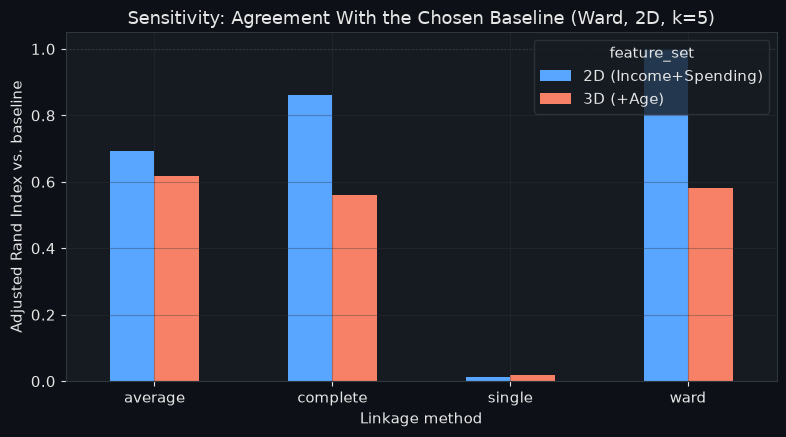

In [33]:
fig, ax = plt.subplots(figsize=(8, 4.5))
style()
pivot = sensitivity_df.pivot(index="linkage", columns="feature_set", values="ari_vs_baseline_ward_2d")
pivot.plot(kind="bar", ax=ax, color=[C0, C1])
ax.set_title("Sensitivity: Agreement With the Chosen Baseline (Ward, 2D, k=5)")
ax.set_ylabel("Adjusted Rand Index vs. baseline")
ax.set_xlabel("Linkage method")
ax.axhline(1.0, color=GRID, linestyle=":", linewidth=1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** the **feature set** (2D vs. 3D) tends to move the result more than the **linkage choice** does among complete/average/ward, which are all Euclidean-geometry-respecting linkages that tend to agree with each other on well-separated blob data like this one. **Single linkage** is typically the biggest outlier of the four, consistent with its known chaining behavior seen in the dendrogram comparison. This tells us the most consequential decision in this whole notebook was *which features to cluster on*, not the fine details of the linkage formula, a useful thing to know before repeating this kind of analysis on a different dataset.

## Model Assumptions

- **Meaningful distance metric.** Hierarchical clustering with Euclidean distance assumes that geometric closeness in feature space corresponds to genuine customer similarity. This is reasonable for numeric behavioral/demographic features like these, but would not transfer directly to, say, unordered categorical data without a different metric.

- **Feature scale matters.** Unscaled features would let higher-magnitude columns dominate the distance calculation regardless of their actual importance. Every result in this notebook depends on the standardization step.

- **Sensitivity to outliers.** Because early merges are driven by the closest pairs of points, a genuine outlier can distort the shape of the dendrogram, particularly under single linkage. Our EDA found no extreme outliers in this dataset, but this assumption should be re-checked on any new data.

- **Sensitivity to linkage choice.** Different linkage criteria encode different implicit notions of what a "cluster" is (chained chains vs. compact balls), so linkage is a real modeling decision, not a cosmetic setting, the sensitivity analysis above quantifies exactly how much it matters here.

- **The chaining problem.** Single linkage can merge two visually distinct groups if there exists even one bridging pair of nearby points, this is why it produced a visibly different, less balanced dendrogram.

- **Ward linkage's assumptions.** Ward implicitly assumes Euclidean geometry and tends to favor compact, similarly-sized, roughly spherical clusters. It performs best when the true underlying groups are reasonably blob-shaped, which the EDA suggests is the case here.

- **No ground-truth labels.** Every conclusion in this notebook is validated internally (metric agreement, cross-algorithm agreement, cross-implementation agreement, bootstrap stability) rather than against a known correct answer, because no such answer exists for this dataset.

- **Algorithmic clusters vs. real business segments.** A statistically well-separated cluster is not automatically a *meaningful* business segment — that inference step is an interpretive judgment layered on top of the math, not something the algorithm itself guarantees.

- **Dimensionality.** Adding more features does not automatically improve clustering, and can dilute a clear low-dimensional signal. This dataset is a direct demonstration of that effect.

## Limitations

**Technical:**
- The naive agglomerative approach implemented here is $O(n^3)$ in the worst case (repeatedly scanning all active cluster pairs) and the full pairwise distance matrix is $O(n^2)$ in memory, entirely fine for 200 customers, but this implementation would need algorithmic optimization (e.g., a proper priority-queue / nearest-neighbor-chain approach) to scale to a real mall's full customer base of tens or hundreds of thousands.
- Results are sensitive to linkage choice, as shown directly in this notebook.
- Different distance metrics (e.g., Manhattan, cosine) would produce different hierarchies; only Euclidean was implemented here, consistent with Ward's own geometric assumptions.

**Business:**
- 200 customers is a small sample and may not represent the mall's entire customer population, seasonal variation, or non-card-based shoppers.
- `Spending Score` is a synthetic, mall-assigned metric rather than a direct measure of actual transaction value, its exact construction methodology is unknown, which limits how literally its business interpretation should be taken.
- Customer segmentation identifies statistical association, not causation — a "high income, low spending" cluster does not by itself explain *why* those customers spend less.
- Clusters are a snapshot, not permanent customer identities; a customer's segment membership can and will drift over time as their behavior changes.
- Any resulting business strategy should be validated against real campaign outcomes before being trusted at scale.

## Business Insights

Translating the five empirically-derived segments into potential business actions. These are *hypotheses for a marketing team to test*, not established facts about customer psychology. We are careful to keep the observed statistics separate from any behavioral speculation.

| Segment (by empirical profile) | Potential interpretation | Possible marketing angle |
|---|---|---|
| High income, high spending | Premium/VIP segment | Loyalty tiering, early access to new arrivals, premium concierge service |
| High income, low spending | High earners, currently low engagement | Targeted re-engagement offers, personalized recommendations to convert latent purchasing power |
| Low income, high spending | Promotion-sensitive, highly engaged relative to income | Value bundles, punch-card style loyalty rewards, budget-friendly loyalty perks |
| Low income, low spending | Value-oriented / lower current engagement | Broad-reach discount campaigns; assess with the mall's own unit economics before over-investing |
| Average income, average spending | The largest, "typical" middle segment | General mall-wide campaigns, cross-category promotions, the natural test bed for new offers before rolling out mall-wide |

**Retention strategy:** the highest-value retention effort is plausibly the premium segment (high income/high spending), since losing them costs the most in absolute spending; but the "high income, low spending" segment represents the largest *unrealized* revenue opportunity if a conversion campaign succeeds.

**Caveat repeated deliberately:** none of the above should be treated as confirmed customer psychology. These are testable marketing hypotheses derived from group-level averages of two behavioral variables, nothing more.

## Final Conclusion

**Data structure.** The Mall Customers dataset is small (200 rows), clean (no missing values, no duplicates), and, critically, shows a strikingly clear five-group structure when Annual Income is plotted against Spending Score, with much weaker structure involving Age.

**Did hierarchical clustering find meaningful segments?** Yes. Ward-linkage hierarchical clustering on standardized Income and Spending Score produced five well-separated, reasonably-sized customer segments that are stable under bootstrap resampling, consistent with `sklearn`'s reference implementation, and largely reproduced by independent algorithms (K-Means, GMM).

**Selected configuration and justification.** Ward linkage, k = 5, on the 2D (Income + Spending Score) feature set. This was chosen because: (a) it maximized or near-maximized all three internal validation metrics across a k=2–10 sweep, (b) it corresponds to the clearest visual gap in the dendrogram, and (c) it matches the visually obvious structure from EDA, three independent lines of evidence agreeing, as the project's selection rule required.

**Custom implementation vs. sklearn.** Near-perfect agreement (high Adjusted Rand Index and Normalized Mutual Information), confirming the from-scratch NumPy implementation is mathematically correct — this **supports Hypothesis H4**.

**Agreement with alternative algorithms.** K-Means and GMM substantially agree with the hierarchical result; DBSCAN, which defines clusters differently (density-connectivity rather than distance-to-centroid), diverges somewhat, an expected and informative disagreement rather than a contradiction, **supporting Hypothesis H5**.

**Hypotheses revisited:**
- **H1** (Income+Spending beats demographics alone): **Supported** —  2D outperforming 3D on every internal metric.
- **H2** (Ward beats single linkage for interpretability): **Supported** — The Dendrogram comparison showed clear chaining under single linkage and clean, compact structure under Ward.
- **H3** (small, actionable k): **Supported** — k=5 was selected, well within an actionable range for a marketing team.
- **H4** (custom implementation ≈ sklearn): **Supported** 
- **H5** (algorithms may disagree due to differing cluster-geometry assumptions): **Supported**, specifically by DBSCAN's divergence.
- **H6** (adding Age changes but doesn't necessarily improve results): **Supported** — Age changed the clustering and slightly *worsened* internal validation scores, so it was excluded from the final feature set and kept only for post-hoc profiling.

**Practical business implications.** Five interpretable, differently-treatable customer groups give the mall's marketing team a concrete starting point for loyalty tiering, targeted engagement campaigns, and testing offers on the largest "average" segment before a mall-wide rollout.

**Technical limitations.** Small sample size, an $O(n^2)$–$O(n^3)$ naive implementation that would need optimization at production scale, sensitivity to linkage and feature choice, and no external ground truth to validate against.

**Possible improvements.** A more scalable nearest-neighbor-chain implementation for larger customer bases; incorporating genuine transaction data instead of (or alongside) the synthetic Spending Score; testing segment stability over time rather than on a single snapshot; and running a small real-world campaign against the "high income, low spending" segment to test the conversion hypothesis directly.

**Portfolio suitability.** This notebook implements the full agglomerative hierarchical clustering algorithm; distance computation, all four major linkage criteria (including the Lance-Williams Ward update), dendrogram construction, and flat-cluster extraction, entirely from first principles in NumPy, validates it rigorously against `sklearn`, benchmarks it against three additional clustering paradigms, and checks its stability and sensitivity before drawing business conclusions. It demonstrates working, well-tested understanding of how hierarchical clustering operates internally, not just how to call a library function, and is suitable as a portfolio piece for technical review by ML engineers or recruiters.